# Forecasting Wind Curtailment Costs in the GB Balancing Mechanism

## Project Overview

Wind curtailment — where wind farms are paid to reduce output due to grid constraints — costs hundreds of millions of pounds annually in the UK. This project uses half-hourly settlement data from Elexon (BOALF, PN, BMU) to forecast the cost of curtailment in the next settlement period for individual wind BMUs.

Two gradient boosting models (LightGBM and XGBoost) are compared using both point and quantile regression, evaluated with RMSE, calibration plots, and pinball loss. SHAP is used for feature importance analysis, and walk-forward validation assesses model robustness across time.

## 1. Data Preparation

The dataset contains half-hourly records for wind BMUs across 2025, derived from Elexon's BMRS data. Each row represents a settlement period where the actual energy output (from BOALF acceptances) differed from expected output (from Physical Notifications), indicating curtailment activity. Key fields include expected and actual MWh, the change in output, and the associated balancing cost.

In [385]:
import pandas as pd
import requests
import csv
import duckdb
import datetime
from pathlib import Path
from dateutil.relativedelta import relativedelta
import itertools
import json

df = pd.read_csv('data/time_data.csv')
df['settlementDate'] = pd.to_datetime(df['settlementDate'])
df['timeFrom'] = pd.to_datetime(df['timeFrom'])
df['timeTo'] = pd.to_datetime(df['timeTo'])
print(df.dtypes)
df.head()

action                           str
fuelType                         str
leadPartyName                    str
gspGroupId                       str
demandCapacity               float64
generationCapacity           float64
BmUnitId                         str
settlementDate        datetime64[us]
settlementPeriod               int64
timeFrom              datetime64[us]
timeTo                datetime64[us]
expected_mwh                 float64
actual_mwh                   float64
change_in_mwh                float64
change_cost                  float64
longitude                    float64
latitude                     float64
dtype: object


,action,fuelType,leadPartyName,gspGroupId,demandCapacity,generationCapacity,BmUnitId,settlementDate,settlementPeriod,timeFrom,timeTo,expected_mwh,actual_mwh,change_in_mwh,change_cost,longitude,latitude
0,Wind curtailed,WIND,Aberdeen Offshore Wind Farm,NaN,-2.0,99.0,ABRBO-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,18.75,18.75,0.0,0.0,-1.972800,57.222600
1,Wind curtailed,WIND,Npower Commercial Gas Limited,_N,-10.0,36.0,ABRTW-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,13.50,13.10,0.4,36.4,-3.988675,55.621764
2,Wind curtailed,WIND,Mobius Renewables Gen. (GB2,NaN,-2.0,42.6,ACHRW-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,21.50,21.50,0.0,0.0,-5.393722,56.342860
3,Wind curtailed,WIND,Afton Wind Farm Limited,NaN,-2.0,50.0,AFTOW-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,17.50,17.50,0.0,0.0,-4.169100,55.312800
4,Wind curtailed,WIND,ENGIE Power Limited,_N,0.0,38.0,AIRSW-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,9.00,9.00,0.0,0.0,-4.713441,54.970896


In [386]:
print(f"Total Expected Wind Generation: {df[df['action'] == 'Wind curtailed']['expected_mwh'].sum()/1000:.2f} GWh")
print(f"Total Actual Wind Generation (GWh): {df[df['action'] == 'Wind curtailed']['actual_mwh'].sum()/1000:.2f} GWh")
print(f"Total Curtailed Wind Generation (GWh): {df[df['action'] == 'Wind curtailed']['change_in_mwh'].sum()/1000:.2f} GWh")
print(f"Total Cost of Wind Curtailment (£M): £{df[df['action'] == 'Wind curtailed']['change_cost'].sum()/1000000:.2f} million")

Total Expected Wind Generation: 81422.83 GWh
Total Actual Wind Generation (GWh): 71105.10 GWh
Total Curtailed Wind Generation (GWh): 10317.74 GWh
Total Cost of Wind Curtailment (£M): £401.50 million


The time series below shows how curtailment costs vary over the year, giving a sense of the volatility and seasonal patterns the model will need to capture:

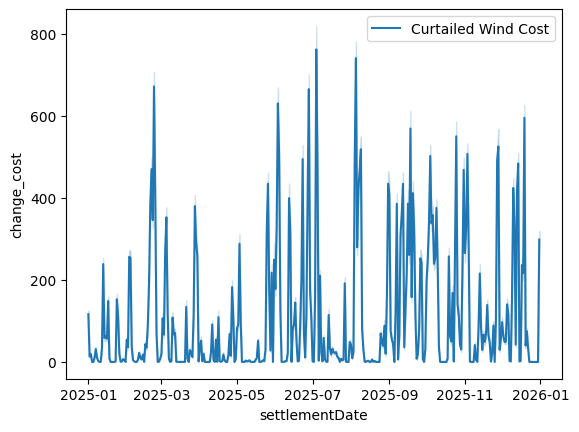

In [387]:
import matplotlib.pyplot as plt
import seaborn as sns

df['dayofyear'] = df['timeFrom'].dt.day_of_year

wind_df = df[df['action'] == 'Wind curtailed']

ax = sns.lineplot(data=wind_df, x='settlementDate',y='change_cost', label='Curtailed Wind Cost')

ax.legend()
plt.show()

## 2. Feature Engineering and Train/Test Split

### Avoiding Data Leakage

This is time-series data, which introduces specific risks that don't exist with cross-sectional data:

- **Temporal splitting** — the train/test split must respect chronological order. A 15-day gap is introduced between the two sets to prevent autocorrelation from leaking information across the boundary.

- **Lag constraints** — lag features must only use data that would genuinely be available at prediction time. For an N-period-ahead forecast, the minimum valid lag is N+1 periods.

- **Target construction** — the target variable (next-period curtailment cost) is created by shifting *before* any row filtering, ensuring the target always corresponds to the true next settlement period rather than an arbitrary surviving row.

### Feature Engineering

Lag features and rolling averages are computed per BMU for key variables (expected MWh, actual MWh, change in MWh, and change cost) at intervals of [2, 3, 4, 5, 6, 12, 24, 48] settlement periods. These capture short-term autocorrelation, intra-day patterns (12 and 24 periods = 6h and 12h), and multi-day trends (48 periods = 24h).

In [388]:
import math

wind_df = df[df['action'] == 'Wind curtailed'].sort_values(['settlementDate','settlementPeriod'])

# Creating gap of 15 days between train and test set

train_cutoff = '2025-10-01'
test_cutoff = '2025-10-15'

train = wind_df[wind_df['settlementDate'] < train_cutoff]
test = wind_df[wind_df['settlementDate'] >= test_cutoff]

def create_features(df, cols, intervals):
    df = df.copy()
    for col in cols:
        for interval in intervals:

            # Create lags and rolling averages of lags

            shifted = df.groupby('BmUnitId')[col].shift(interval)
            df[f'{col}_lag{interval}'] = shifted
            df[f'{col}_lag{interval}_roll{interval}'] = shifted.groupby(df['BmUnitId']).rolling(interval).mean().reset_index(level=0,drop=True)

    # Encode day of year and day of week cyclically using sin and cos

    df['dayofyear_x'] = df['dayofyear'].apply(lambda x: math.sin(2*math.pi*x/365))
    df['dayofyear_y'] = df['dayofyear'].apply(lambda x: math.cos(2*math.pi*x/365))
    
    df['dayofweek'] = df['settlementDate'].dt.day_of_week
    df['dayofweek_x'] = df['dayofweek'].apply(lambda x: math.sin(2*math.pi*x/7))
    df['dayofweek_y'] = df['dayofweek'].apply(lambda x: math.cos(2*math.pi*x/7))
    
    return df

lag_cols = ['expected_mwh','actual_mwh','change_in_mwh','change_cost']
intervals = [2,3,4,5,6,12,24,48]

X_train = create_features(train, lag_cols, intervals)
X_test = create_features(test, lag_cols, intervals)

X_train.head()

,action,fuelType,leadPartyName,gspGroupId,demandCapacity,generationCapacity,BmUnitId,settlementDate,settlementPeriod,timeFrom,...,change_cost_lag12_roll12,change_cost_lag24,change_cost_lag24_roll24,change_cost_lag48,change_cost_lag48_roll48,dayofyear_x,dayofyear_y,dayofweek,dayofweek_x,dayofweek_y
0,Wind curtailed,WIND,Aberdeen Offshore Wind Farm,NaN,-2.0,99.0,ABRBO-1,2025-01-01,1,2025-01-01,...,NaN,NaN,NaN,NaN,NaN,0.017213,0.999852,2,0.974928,-0.222521
1,Wind curtailed,WIND,Npower Commercial Gas Limited,_N,-10.0,36.0,ABRTW-1,2025-01-01,1,2025-01-01,...,NaN,NaN,NaN,NaN,NaN,0.017213,0.999852,2,0.974928,-0.222521
2,Wind curtailed,WIND,Mobius Renewables Gen. (GB2,NaN,-2.0,42.6,ACHRW-1,2025-01-01,1,2025-01-01,...,NaN,NaN,NaN,NaN,NaN,0.017213,0.999852,2,0.974928,-0.222521
3,Wind curtailed,WIND,Afton Wind Farm Limited,NaN,-2.0,50.0,AFTOW-1,2025-01-01,1,2025-01-01,...,NaN,NaN,NaN,NaN,NaN,0.017213,0.999852,2,0.974928,-0.222521
4,Wind curtailed,WIND,ENGIE Power Limited,_N,0.0,38.0,AIRSW-1,2025-01-01,1,2025-01-01,...,NaN,NaN,NaN,NaN,NaN,0.017213,0.999852,2,0.974928,-0.222521


In [389]:
# Drop columns before creating training and testing sets

drop_cols = ['action','fuelType','timeFrom','timeTo','settlementDate']
drop_cols.append('gspGroupId')
for col in lag_cols:
    drop_cols.append(col)


# Target variable: change_cost

Y_h1_train = X_train.groupby('BmUnitId').shift(-1)['change_cost']

X_train = X_train[Y_h1_train.notna()]
Y_h1_train = Y_h1_train[Y_h1_train.notna()]


Y_h1_test = X_test.groupby('BmUnitId').shift(-1)['change_cost']

X_test = X_test[Y_h1_test.notna()]
Y_h1_test = Y_h1_test[Y_h1_test.notna()]

mask_train = X_train['change_cost'] > 0
mask_test = X_test['change_cost'] > 0

X_train = X_train[mask_train]
Y_h1_train = Y_h1_train[mask_train]

X_test = X_test[mask_test]
Y_h1_test = Y_h1_test[mask_test]

X_train = X_train.drop(columns=drop_cols, errors='ignore')
X_test = X_test.drop(columns=drop_cols, errors='ignore')



# Check that length of training set matches after dropping NA's

print(Y_h1_train.isna().sum())
print(f'Length of Y_train: {len(Y_h1_train)}')
print(f'Length of X_train: {len(X_train)}')


0
Length of Y_train: 170778
Length of X_train: 170778


In [390]:
# Temporal validation of train and test sets

train_min = X_train['dayofyear'].min()
train_max = X_train['dayofyear'].max()
test_min = X_test['dayofyear'].min()
test_max = X_test['dayofyear'].max()

print(f'Training set day range: {train_min} to {train_max}')
print(f'Test set day range: {test_min} to {test_max}')

Training set day range: 1 to 273
Test set day range: 291 to 365


## 3. LightGBM

LightGBM is a gradient boosting framework that builds an ensemble of decision trees sequentially, where each new tree targets the residual errors of the previous ones. Two features distinguish it from other boosting implementations:

- **Gradient-based One-Side Sampling (GOSS)** — prioritises training on instances with larger gradients (i.e. larger errors), reducing computation without significantly hurting accuracy.
- **Exclusive Feature Bundling (EFB)** — bundles mutually exclusive features together, reducing the effective number of features the algorithm needs to consider.

LightGBM also grows trees leaf-wise rather than level-wise, expanding whichever leaf most reduces the loss. This tends to produce more accurate models with fewer iterations, though it can overfit on small datasets. Categorical features like BmUnitId are handled natively without one-hot encoding.

In [391]:
import lightgbm as lgb
import numpy as np

categorical_features = ['BmUnitId', 'leadPartyName']

lgbm_model_h1 = lgb.LGBMRegressor()

# Setting categorical columns as type category

lgbm_xtrain = X_train.copy()
for cat in categorical_features:
    lgbm_xtrain[cat] = lgbm_xtrain[cat].astype('category')

lgbm_xtest = X_test.copy()
for cat in categorical_features:
    lgbm_xtest[cat] = lgbm_xtest[cat].astype('category')

lgbm_model_h1.fit(lgbm_xtrain,Y_h1_train,categorical_feature=categorical_features)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004633 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17710
[LightGBM] [Info] Number of data points in the train set: 170778, number of used features: 77
[LightGBM] [Info] Start training from score 1539.285463


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


RMSE measures the average magnitude of prediction error in the same units as the target (£). Comparing it against the distribution of actual values (mean, standard deviation, quartiles) gives context for how meaningful the error is:

count    58747.000000
mean      1688.485787
std       2311.950054
min          0.000000
25%        455.694333
50%        892.467750
75%       2157.764625
max      69383.360000
Name: change_cost, dtype: float64
RMS error between actual vs prediction: 1113.3902548401932


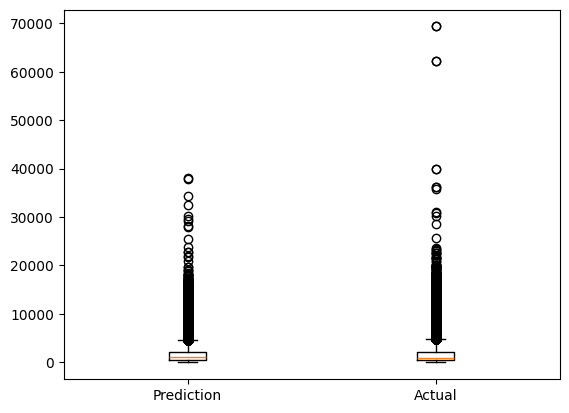

In [392]:
from sklearn.metrics import root_mean_squared_error

predictions_h1 = lgbm_model_h1.predict(lgbm_xtest)

mask = Y_h1_test.notna()
Y_h1_test_clean = Y_h1_test[mask]
predictions_h1_clean = predictions_h1[mask]



error_h1 = root_mean_squared_error(Y_h1_test_clean,predictions_h1_clean)
print(Y_h1_test.describe())
print(f'RMS error between actual vs prediction: {error_h1}')

plt.boxplot([predictions_h1,Y_h1_test_clean], tick_labels=['Prediction','Actual'])
plt.show()

The boxplots show that the model captures the central tendency well but struggles at the extremes, it doesn't predict the high-cost outliers present in the actual data. This is a common limitation of point regression on heavy-tailed distributions, and motivates the use of quantile regression below.

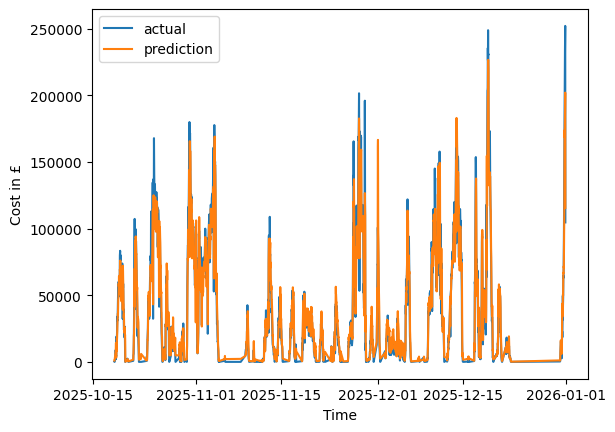

In [393]:
import plotly.express as px

X_test_final = X_test.copy()
X_test_final['1period_actual'] = Y_h1_test
X_test_final['1period_prediction'] = predictions_h1
X_test_final['time'] = wind_df['timeFrom']

test_by_period = X_test_final.groupby('time')[['1period_actual','1period_prediction']].sum().reset_index()

sns.lineplot(data=test_by_period,x='time',y='1period_actual', label='actual')
sns.lineplot(data=test_by_period,x='time',y='1period_prediction',label='prediction')
plt.xlabel('Time')
plt.ylabel('Cost in £')
plt.show()

## 4. Quantile Regression

A point forecast gives a single expected value but says nothing about how confident that estimate is. In energy balancing markets, understanding the *range* of likely outcomes matters. A participator needs to know not just the expected curtailment cost, but the probability of it exceeding a given threshold.

Quantile regression addresses this by training separate models for each quantile (10th through 90th percentile). Rather than minimising squared error, each model minimises an asymmetric loss function (the pinball loss) that penalises over- and under-prediction differently depending on the target quantile. The result is a set of prediction intervals that characterise the full distribution of possible outcomes.

In [394]:
quantiles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Training a separate model for each quantile

lgbm_models = {}

for quantile in quantiles:
    model = lgb.LGBMRegressor(objective='quantile',alpha=quantile)
    model.fit(lgbm_xtrain,Y_h1_train)
    lgbm_models[quantile] = model

lgbm_quantile_predictions = {}

for alpha, model in lgbm_models.items():
    prediction = model.predict(lgbm_xtest,categorical_feature=categorical_features)
    lgbm_quantile_predictions[alpha] = prediction

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014493 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17710
[LightGBM] [Info] Number of data points in the train set: 170778, number of used features: 77
[LightGBM] [Info] Start training from score 33.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004020 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17710
[LightGBM] [Info] Number of data points in the train set: 170778, number of used features: 77
[LightGBM] [Info] Start training from score 122.589996
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008545 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] T

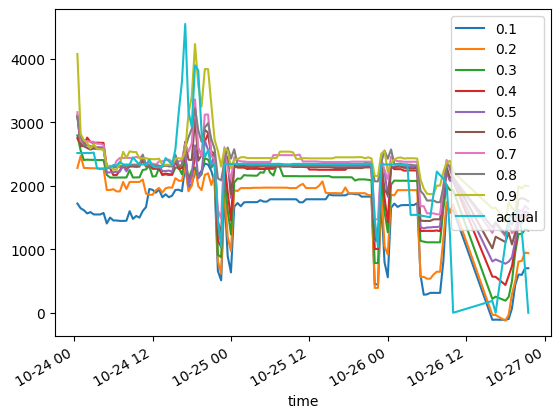

In [395]:
lgbm_quantile_df = pd.DataFrame(lgbm_quantile_predictions, index=X_test.index).dropna()
lgbm_quantile_df['actual'] = Y_h1_test
lgbm_quantile_df['time'] = wind_df['timeFrom']
lgbm_quantile_df['BmUnitId'] = X_test['BmUnitId']

view_df = lgbm_quantile_df[(lgbm_quantile_df['BmUnitId'] == 'SGRWO-1') & (lgbm_quantile_df['time'] < '2025-10-27') & (lgbm_quantile_df['time'] > '2025-10-24')]

view_df.plot.line(x='time', stacked=False)
plt.show()

The plot above reveals quantile crossover at several points. This happens because each quantile model is trained independently and isn't constrained to maintain ordering. It's more pronounced during periods of high volatility.

A calibration plot provides a complementary diagnostic: for the Nth percentile prediction, we'd expect N% of actual observations to fall below it. Plotting the predicted quantile against the observed coverage rate shows how well-calibrated the model is:

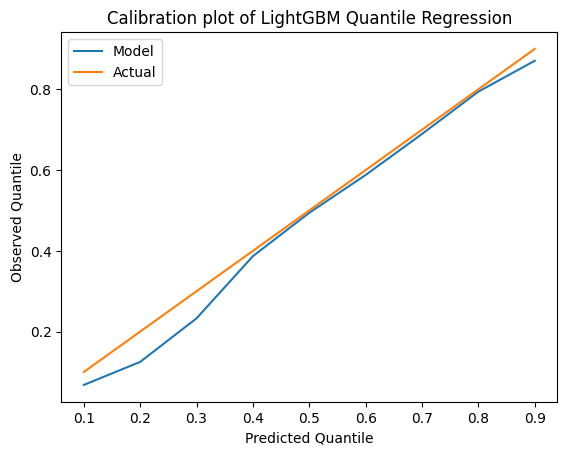

In [396]:
lgbm_actual_coverage = {}
for quantile in quantiles:
    model_quantile = float((lgbm_quantile_df['actual'] <= lgbm_quantile_df[quantile]).mean())
    lgbm_actual_coverage[quantile] = model_quantile

plt.plot(lgbm_actual_coverage.keys(), list(lgbm_actual_coverage.values()), label='Model')
plt.plot(quantiles, list(lgbm_actual_coverage.keys()), label='Actual')
plt.legend()
plt.xlabel('Predicted Quantile')
plt.ylabel('Observed Quantile')
plt.title('Calibration plot of LightGBM Quantile Regression')
plt.show()


The calibration is reasonable overall, though the model underestimates at both tails. Without weather data (wind speed forecasts, gust predictions), the model has no direct signal for when conditions will drive unusually high or low curtailment.

## 5. XGBoost

XGBoost is compared as a second gradient boosting implementation. Its key architectural difference is level-wise tree growth. At each iteration it expands all leaves at the current depth before moving deeper. This is generally more conservative than LightGBM's leaf-wise approach and can be more robust against overfitting, though it may require more iterations to reach the same accuracy.

In [397]:
import xgboost as xgb

xgb_models = {}

xgb_xtrain = X_train.copy()
xgb_xtest = X_test.copy()

for cat in categorical_features:
    xgb_xtrain[cat] = xgb_xtrain[cat].astype('category')
    xgb_xtrain[cat] = xgb_xtrain[cat].cat.codes

    xgb_xtest[cat] = xgb_xtest[cat].astype('category')
    xgb_xtest[cat] = xgb_xtest[cat].cat.codes

quantiles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for q in quantiles:
    model = xgb.XGBRegressor(objective='reg:quantileerror',quantile_alpha=q,enable_categorical=True)
    model.fit(xgb_xtrain,Y_h1_train)
    xgb_models[q] = model


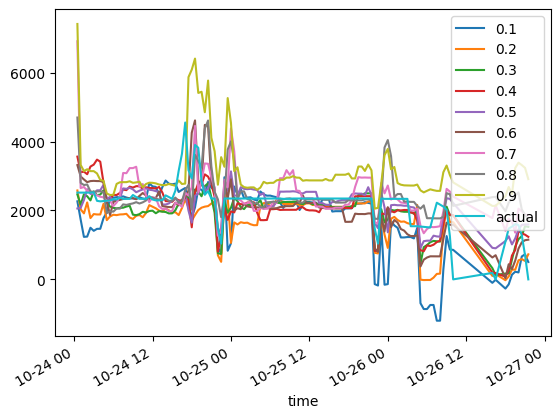

In [398]:
xgb_quantile_predictions = {}

for quantile, model in xgb_models.items():
    prediction = model.predict(xgb_xtest)
    xgb_quantile_predictions[quantile] = prediction

xgb_quantile_df = pd.DataFrame(xgb_quantile_predictions, index=X_test.index).dropna()
xgb_quantile_df['actual'] = Y_h1_test
xgb_quantile_df['time'] = wind_df['timeFrom']
xgb_quantile_df['BmUnitId'] = X_test['BmUnitId']

view_df = xgb_quantile_df[(xgb_quantile_df['BmUnitId'] == 'SGRWO-1') & (xgb_quantile_df['time'] < '2025-10-27') & (xgb_quantile_df['time'] > '2025-10-24')]

view_df.plot.line(x='time', stacked=False)
plt.show()


XGBoost shows considerably more quantile crossover than LightGBM on default hyperparameters, with the lower quantile predictions being notably unstable during volatile periods. This suggests the model struggles more to differentiate between quantile levels without tuning.

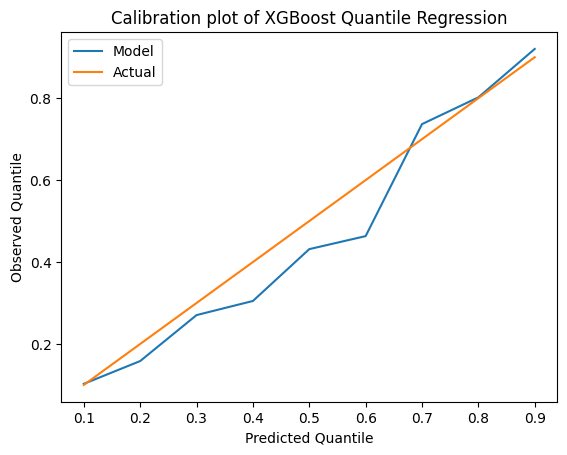

In [399]:
xgb_actual_coverage = {}
for quantile in quantiles:
    model_quantile = float((xgb_quantile_df['actual'] <= xgb_quantile_df[quantile]).mean())
    xgb_actual_coverage[quantile] = model_quantile

plt.plot(xgb_actual_coverage.keys(), list(xgb_actual_coverage.values()), label='Model')
plt.plot(quantiles, list(xgb_actual_coverage.keys()), label='Actual')
plt.legend()
plt.xlabel('Predicted Quantile')
plt.ylabel('Observed Quantile')
plt.title('Calibration plot of XGBoost Quantile Regression')
plt.show()


XGBoost's calibration is less consistent, deviating from the diagonal at intermediate quantiles as well as the tails. However, calibration plots have an important limitation: they only measure *average* coverage. A model could systematically overpredict for one BMU and underpredict for another, yet still appear well-calibrated in aggregate because the errors cancel out.

### Pinball Loss

Pinball loss addresses this by penalising the *magnitude* of each individual quantile error, not just whether the observation fell above or below the prediction. It applies an asymmetric weighting — for the Nth percentile, underpredictions are penalised at rate N and overpredictions at rate (1-N). Lower scores indicate sharper, better-calibrated quantile predictions. Because it scores each observation individually, offsetting errors in opposite directions still accumulate rather than cancelling.

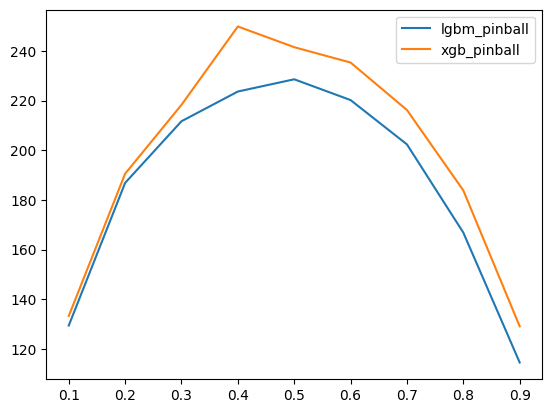

In [400]:
from sklearn.metrics import mean_pinball_loss

lgbm_plosses = {}
xgb_plosses = {}

for q, p in lgbm_quantile_predictions.items():
    lgbm_plosses[q] = mean_pinball_loss(Y_h1_test,p,alpha=q)

for q, p in xgb_quantile_predictions.items():
    xgb_plosses[q] = mean_pinball_loss(Y_h1_test,p,alpha=q)

pinball_losses_df = pd.DataFrame({'lgbm_pinball':lgbm_plosses, 'xgb_pinball':xgb_plosses})
pinball_losses_df.plot()
plt.show()

LightGBM achieves a lower pinball loss across all quantiles, confirming it produces sharper and better-calibrated uncertainty estimates than XGBoost on default settings. The characteristic hump shape (higher loss at middle quantiles, lower at extremes) is expected as it reflects the asymmetric weighting of pinball loss rather than model weakness at those quantiles.

## 6. Feature Importance

Understanding which features drive predictions serves two purposes: validating that the model has learned sensible patterns (not data leakage), and gaining domain insight into what drives curtailment costs.

Three common approaches exist for tree-based models:

- **Split-based importance** counts how often a feature is used for splits. This is unreliable for high-cardinality categoricals — a feature like BmUnitId with dozens of categories will accumulate splits simply because it offers more candidate split points, not because each split is individually important.

- **Permutation importance** measures the drop in model performance when a feature's values are randomly shuffled, capturing its true contribution to accuracy.

- **SHAP (SHapley Additive exPlanations)** uses concepts from cooperative game theory to attribute each prediction to its constituent features, providing both global importance rankings and per-observation explanations.

SHAP is used here as it provides the richest picture and handles categorical features fairly:

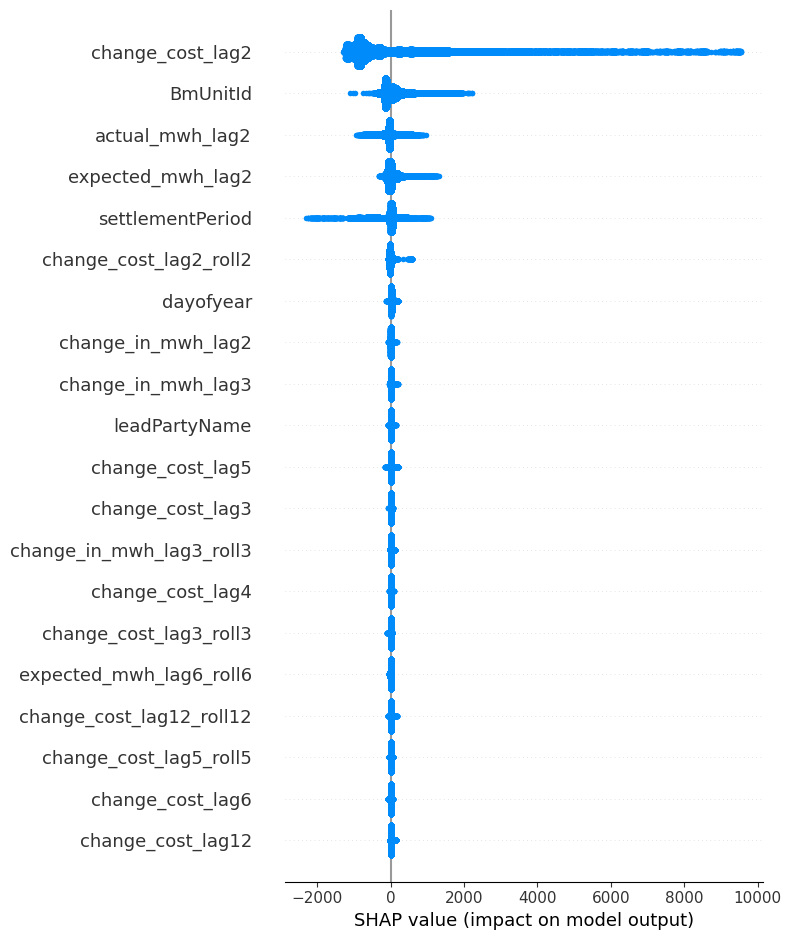

In [401]:
import numpy
import shap

explainer = shap.TreeExplainer(lgbm_models[0.5])
shap_values_lgbm = explainer.shap_values(lgbm_xtest)
shap.summary_plot(shap_values=shap_values_lgbm, feature_names = lgbm_xtest.columns.tolist())

The most influential feature is the most recent change_cost lag, which a direct result of autocorrelation in the time series. BmUnitId ranks highly because it acts as a proxy for multiple physical characteristics (capacity, location). Settlement period surprisingly has a negative impact in many instances, perhaps because wind patterns aren't as cyclical in the day as expected.

Notably, latitude and longitude show minimal importance despite being included. This is likely because BmUnitId already encodes location implicitly. The model doesn't need geographic coordinates when it can learn location-specific patterns directly from the BMU identifier.

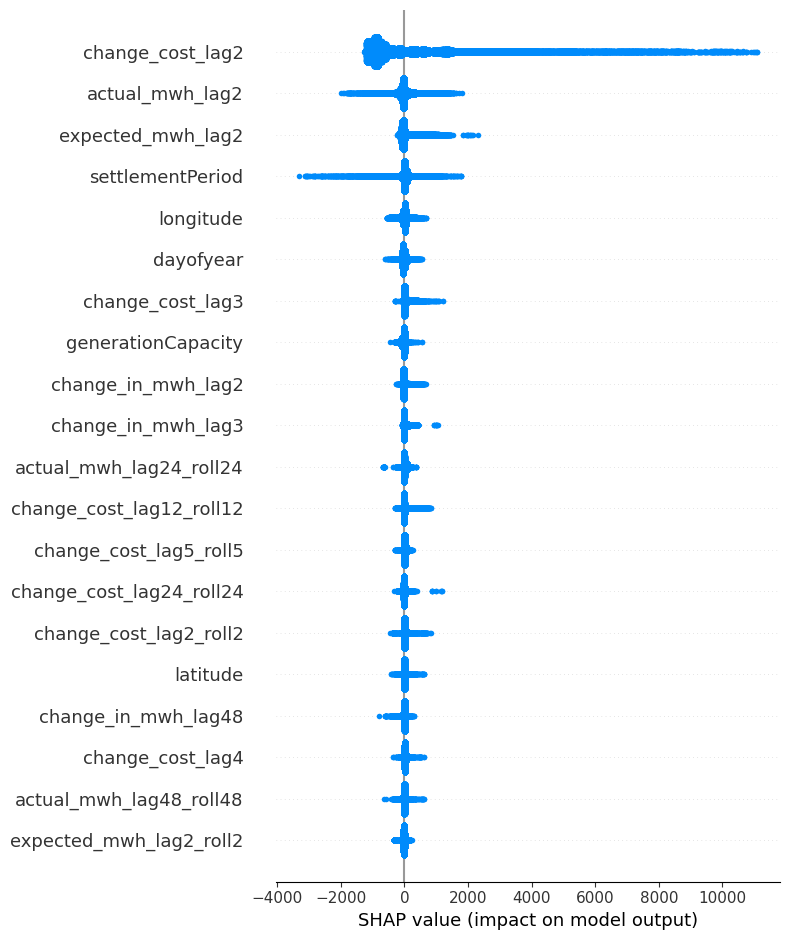

In [402]:
explainer = shap.TreeExplainer(xgb_models[0.5])
shap_values_xgb = explainer.shap_values(xgb_xtest)
shap.summary_plot(shap_values=shap_values_xgb, feature_names = xgb_xtest.columns.tolist())

The most interesting differences here is the low importance of BmUnitId and the stronger reliance on longitude, interesting for two reasons:

- This is likely a result of the depth-wise growth of XGBoost. It learned the general trend of longitude affecting curtailment, while LightGBM just relied on BmUnitId as a proxy - something it could do more easily by splitting leaf-wise.

- It uses longitude (east-west) rather than latitude (north-south), which seems counterintuitive given the 

## 7. Walk-Forward Validation

Standard k-fold cross-validation randomly assigns observations to folds, which would violate temporal ordering and leak future information into training sets. Walk-forward validation respects the time series structure by using expanding training windows:

- **Fold 0**: Train on Jan–Mar, test on Apr onward
- **Fold 1**: Train on Jan–Jun, test on Jul onward
- **Fold 2**: Train on Jan–Sep, test on Oct onward

Each fold simulates a realistic deployment scenario where the model is retrained as more data becomes available. Consistent performance across folds suggests the model generalises well; degradation in early folds (with less training data) may be expected.

Three forecast horizons are compared (1, 2, and 3 periods ahead) to assess how prediction quality degrades with increasing lead time.

In [403]:
def prepare_data(df, lag_cols, forecast):
    df = df.copy()

    lag = forecast + 1
    lag_intervals = [lag + i for i in range(4)]  # short-range: [2,3,4,5] for forecast=1
    lag_intervals.extend([12, 24, 48])            # keep the fixed long-range lags

    for col in lag_cols:
        for interval in lag_intervals:
            shifted = df.groupby('BmUnitId')[col].shift(interval)
            df[f'{col}_lag{interval}'] = shifted
            df[f'{col}_lag{interval}_roll{interval}'] = shifted.groupby(df['BmUnitId']).rolling(interval).mean().reset_index(level=0,drop=True)

    df['dayofyear_x'] = df['dayofyear'].apply(lambda x: math.sin(2*math.pi*x/365))
    df['dayofyear_y'] = df['dayofyear'].apply(lambda x: math.cos(2*math.pi*x/365))
    
    df['dayofweek'] = df['settlementDate'].dt.day_of_week
    df['dayofweek_x'] = df['dayofweek'].apply(lambda x: math.sin(2*math.pi*x/7))
    df['dayofweek_y'] = df['dayofweek'].apply(lambda x: math.cos(2*math.pi*x/7))

    categorical_cols = df.select_dtypes(include=['object','str'])

    for col in categorical_cols:
        df[col] = df[col].astype('category')
    
    drop_cols = ['action','fuelType','timeFrom','timeTo','settlementDate']
    drop_cols.append('gspGroupId')
    for col in lag_cols:
        drop_cols.append(col)
    
    

    Y = df.groupby('BmUnitId').shift(-1 * forecast)['change_cost']
    valid = df.drop(columns=drop_cols, errors='ignore').notna().all(axis=1) & Y.notna()
    X = df.drop(columns=drop_cols, errors='ignore')[valid]
    Y = Y[valid]

    zero_mask = Y > 0
    X = X[zero_mask]
    Y = Y[zero_mask]

    return X, Y


def create_folds(df,cutoffs, forecast):
    folds = {}
    start = '2025-01-01'
    for i, cutoff in enumerate(cutoffs):
        fold = {}
        train = df[(df['settlementDate'] >= start) & (df['settlementDate'] < cutoff)]
        test = df[(df['settlementDate'] > cutoff)]
        X_train, Y_train = prepare_data(train, lag_cols, forecast)
        fold['X_train'] = X_train
        fold['Y_train'] = Y_train
        X_test, Y_test = prepare_data(test, lag_cols, forecast)
        fold['X_test'] = X_test
        fold['Y_test'] = Y_test
        folds[i] = fold
    return folds


In [404]:
cutoffs = ['2025-04-01', '2025-07-01', '2025-10-01']

folds_1 = create_folds(wind_df, cutoffs, 1)
folds_2 = create_folds(wind_df, cutoffs, 2)
folds_3 = create_folds(wind_df, cutoffs, 3)

In [405]:
def process_folds(folds):
    for num, fold in folds.items():
        model = lgb.LGBMRegressor()
        fold['model'] = model.fit(fold['X_train'],fold['Y_train'], )
        fold['Y_pred'] = model.predict(fold['X_test'])
        fold['rmse'] = root_mean_squared_error(fold['Y_test'],fold['Y_pred'])
        fold['mae'] = np.mean(np.abs(fold['Y_test']-fold['Y_pred']))
    return folds

folds_1_processed = process_folds(folds_1)
folds_2_processed = process_folds(folds_2)
folds_3_processed = process_folds(folds_3)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15109
[LightGBM] [Info] Number of data points in the train set: 59434, number of used features: 69
[LightGBM] [Info] Start training from score 1146.354686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15414
[LightGBM] [Info] Number of data points in the train set: 107124, number of used features: 69
[LightGBM] [Info] Start training from score 1396.964826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003310 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is 

RMSE and MAE for each forecast horizon and fold:

In [ ]:
def report_folds(folds, name):
    print(f'Results for {name}')
    for i, fold in folds.items():
        print(f"Fold {i}: RMSE={fold['rmse']:.2f}, MAE={fold['mae']:.2f}")

report_folds(folds_1_processed, '1 ahead')
report_folds(folds_2_processed, '2 ahead')
report_folds(folds_3_processed, '3 ahead')

Results for 1 ahead
Fold 0: RMSE=1457.59, MAE=614.71
Fold 1: RMSE=1265.56, MAE=530.14
Fold 2: RMSE=1000.32, MAE=419.32
Results for 2 ahead
Fold 0: RMSE=1687.26, MAE=766.47
Fold 1: RMSE=1415.59, MAE=621.77
Fold 2: RMSE=1118.99, MAE=502.07
Results for 3 ahead
Fold 0: RMSE=1803.70, MAE=846.00
Fold 1: RMSE=1549.25, MAE=708.56
Fold 2: RMSE=1196.04, MAE=555.47


Performance improves substantially with larger training sets, with the earliest fold (Jan–Mar) having notably higher error than the later folds. This is expected as three months of data doesn't capture enough variety in curtailment patterns. Adding historical data from previous years would likely help, particularly for capturing seasonal trends. Error also increases with forecast horizon, as the model loses the benefit of the most recent lag features.

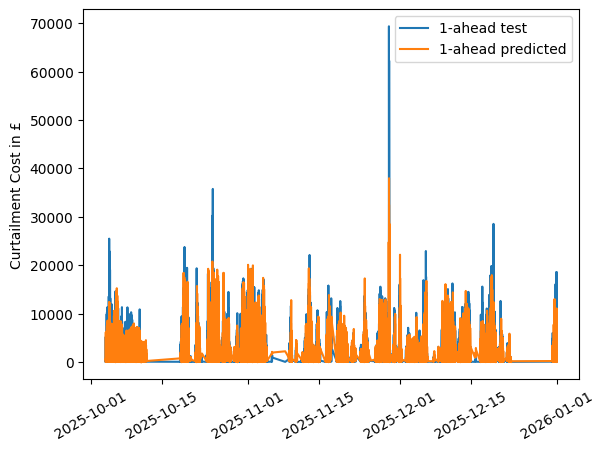

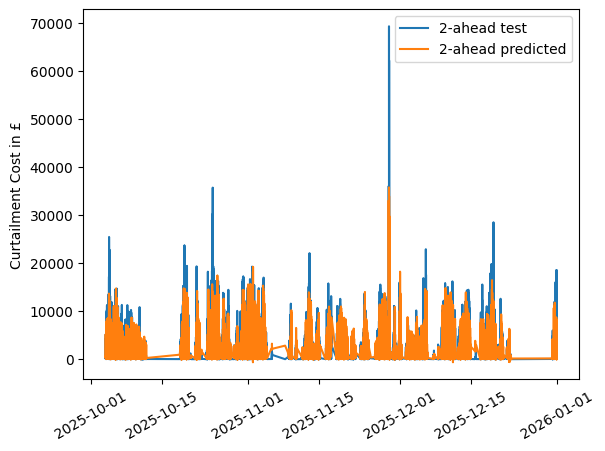

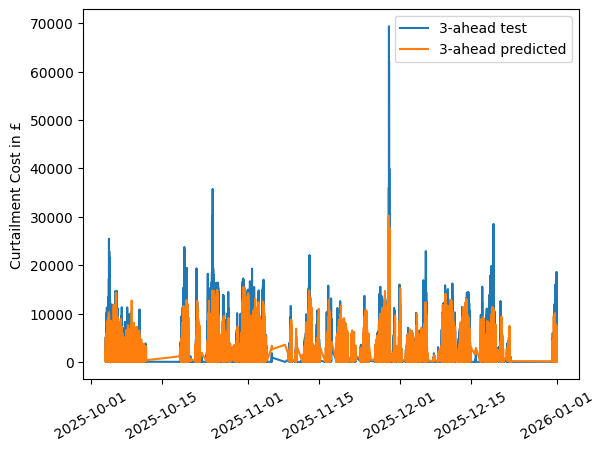

In [411]:
def plot_folds(folds_dict):
    for name, folds in folds_dict.items():
        fold = folds[2]
        fold['X_test']['Y_test'] = fold['Y_test']
        fold['X_test']['Y_pred'] = fold['Y_pred']
        fold['X_test']['time'] = wind_df['timeFrom']
        plt.plot(fold['X_test']['time'],fold['X_test']['Y_test'], label=f'{name} test')
        plt.plot(fold['X_test']['time'],fold['X_test']['Y_pred'], label=f'{name} predicted')
        plt.xticks(rotation=30)
        plt.ylabel('Curtailment Cost in £')
        plt.legend()
        plt.show()

folds_dict = {'1-ahead':folds_1_processed, '2-ahead':folds_2_processed,'3-ahead':folds_3_processed}

plot_folds(folds_dict)

## Conclusions

LightGBM outperformed XGBoost across point regression (RMSE), quantile calibration, and pinball loss on default hyperparameters. SHAP analysis revealed that the two models learn different representations — LightGBM relies on BMU identity while XGBoost favours geographic features — a consequence of their different tree growth strategies.

Walk-forward validation confirmed that model performance is sensitive to training set size, with earlier folds (less data) producing substantially higher error. Forecast quality also degrades with horizon length, as expected for an autoregressive feature set.

Several improvements could meaningfully reduce error:

- **Weather data** — wind speed and gust forecasts would give the model a direct signal for the conditions that drive curtailment, addressing the main weakness identified in the quantile analysis.
- **More training data** — extending beyond a single year would allow the model to learn seasonal patterns and improve early-fold performance.
- **Hyperparameter tuning** — systematic search over learning rate, tree depth, regularisation parameters, and minimum samples per leaf could improve both models, particularly XGBoost's quantile regression.
- **Additional features** — grid constraint data, interconnector flows, or demand forecasts could capture system-level drivers of curtailment that BMU-level features alone cannot.